# Lab Guide for Noise Parameter Measurements for any LNA

In this notebook, we will go through the measurements needed to obtain the set of frequency-dependent noise parameters for any LNA. We will use the LNA12 as an example, but the same procedure can be applied to any LNA. 

In general, for any two-port device, we have
$$
F = F_{min} + \frac{R_n}{G_S} |Y_S - Y_{opt}|^2
$$
where F is the noise figure. The set of noise parameters are $\{F_{min}, R_n, Y_{opt}=G_{opt}+jB_{opt}\}$. We can reparameterize so that this becomes linear:
$$ F_i = \vec{A_i} \cdot \vec{x_i}$$
where $\vec{A_i} = [1, \frac{|Y_{S_i}|^2}{G_{S_i}}, \frac{1}{G_{S_i}}, \frac{B_{S_i}}{G_{S_i}}]$.

Regardless, we need to obtain noise emitted by LNA with four different source admittances. To do this, we first need to subtract away any noise contributed by the measurement system itself and any Johnson noise.

In [1]:
# import necessary modules
import os
from os.path import join as pjoin
import numpy as np
from matplotlib import pyplot as plt
import skrf as rf
from scipy.constants import Boltzmann as kB
import matplotlib.colors as mcolors

pjoin = os.path.join
pbase = os.path.basename

%load_ext autoreload
%autoreload 2

# import relevant classes from highz_exp
from highz_exp.spec_class import Spectrum
from highz_exp.load_trc import TraceLoader
from highz_exp.s_params import S_Params
from highz_exp import plotter, circuit_model, unit_convert
from highz_exp.reflection_proc import reflection_coefficient
import pickle
from highz_exp.fit_temperature import fill_nan_with_fit, NF_Parameters_Fitter


cmap = plt.get_cmap('Accent')

## Calibrate away system noise and gain
The first step is to perform two-stage Y-factor measurements to obtain the system noise temperature and gain. This requires another amplifier after the LNA. Details can be found in the [Amplifier Measurement](amplifier_measurements.ipynb) notebook.

In [2]:
data_path = os.path.expanduser("~/Desktop/High-Z/long_cable")

with open(pjoin(data_path, 'LNA12_noise_temp.pkl'), 'rb') as f:
    LNA_temp = pickle.load(f) 

We then need S11 measurements for the four source admittances prepared. In our experiment, the admittances are prepared by terminating an 8' long cable with four different resistors (62.2 Ohm, 99 Ohm, 351 Ohm, 699 Ohm)

In [3]:
# load source S11s
src_s11s = S_Params(s_params_files=[pjoin(data_path, fn) 
    for fn in ['62OHM.S1P', '99OHM.S1P', '351OHM.S1P', '699OHM.S1P']], 
    labels=['62 Ohm', '99 Ohm', '351 Ohm', '699 Ohm'], 
    colorcode=['salmon', 'blue', 'green', 'purple'])

Uncomment the following cell to visualize the four source admittances.

In [4]:
# src_s11s.plot_smith_chart()
# src_s11s.plot_reflection_loss()
# src_s11s.plot_magnitude_phase()

In [5]:
# Make sure all objects have the same frequency axis
resample_freq = LNA_temp.f[(LNA_temp.f >= 25e6) & (LNA_temp.f <= 250e6)]
LNA_temp.resample(resample_freq)
src_s11s.interpolate_all(resample_freq)

# load all relevant system parameters for subtraction away from measurements
system_gain = fill_nan_with_fit(LNA_temp.f, 10**(LNA_temp.g_sys/10))
LNA_noise_50 = fill_nan_with_fit(LNA_temp.f, LNA_temp.T_dut)
system_noise = fill_nan_with_fit(LNA_temp.f, LNA_temp.T_sys) - LNA_noise_50  # excluding LNA noise contribution

system_noise_spec = Spectrum(LNA_temp.f, system_noise, name='System Noise Temperature', colorcode='red')
LNA_noise_50_spec = Spectrum(LNA_temp.f, LNA_noise_50, name='LNA Noise Temperature (50 Ohm)', colorcode='magenta')

# Uncomment below to visualize system_noise
# system_noise_spec.plot(ylabel='Noise Temperature (K)', title='Noise contribution from second-stage amplifier',
#     y_range=(0, 20))

We also need S11 measurement of LNA.

In [6]:
LNA_ntwk = rf.Network(pjoin(data_path, 'LNA12.S1P'))
LNA_ntwk = LNA_ntwk.interpolate(src_s11s.ntwk_dict['351 Ohm'].f)

Use the same measurement system, we then measure spectra for the four different source admittances.

In [7]:
trc_file = pjoin(data_path, "peaks_0521.trc")

loader = TraceLoader(trc_file)
trace = loader.load_trace(1)
ohm_99 = Spectrum(trace[0], trace[1], name='8" Cable - 99 Ohm', colorcode='blue').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
trace = loader.load_trace(2)
ohm_351 = Spectrum(trace[0], trace[1], name='8" Cable - 351 Ohm', colorcode='green').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)

trc_file = pjoin(data_path, "peaks_0529.trc")
loader = TraceLoader(trc_file)
trace = loader.load_trace(1)
ohm_62 = Spectrum(trace[0], trace[1], name='8" Cable - 62 Ohm', colorcode='salmon').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
trace = loader.load_trace(2)
ohm_699 = Spectrum(trace[0], trace[1], name='8" Cable - 699 Ohm', colorcode='purple').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)

ohm_50 = Spectrum(LNA_temp.f, LNA_temp.DUT_hot, name='50 Ohm', colorcode='orange')

In [8]:
# Uncomment below to visualize the four spectra

# plotter.plot_spectra([ohm_62, ohm_99, ohm_351, ohm_699, ohm_50], marker='o', ms=2, ls='',
#     title='Measured Spectra for Different Source Admittances', y_range=(0, 1e6),
#     ylabel='Noise Temperature (K)')

We then subtract away system gain and contribution from the second-stage amplifier.

In [9]:
for spec in [ohm_62, ohm_99, ohm_351, ohm_699, ohm_50]:
    spec.resample(LNA_temp.f)
    spec.s = spec.s / system_gain
    spec.s = spec.s - system_noise
    # spec = spec.filter_by_spline_fit(inplace=False, rel_tol=0.05)

In [10]:
# Uncomment below to visualize again

# plotter.plot_spectra([ohm_62, ohm_99, ohm_351, ohm_699, ohm_50],
#     title='Measured Spectra (exclude second-stage amplifier contribution)', ls='',
#     ylabel='Noise Temperature (K)', y_range=(0, 2000), marker='o', markersize=2)

## Model and subtract away Johnson noise contribution

We model our set-up with a double emitter circuit, where there are two sources of noise: the noise emitted by the LNA, and the Johnson noise from the source. In order to obtain the LNA contribution, we need to model the Johnson noise contribution and subtract it away. This only requires the source admittance measurements already obtained before. 

In [11]:
colorkeys = mcolors.CSS4_COLORS.keys()

reflection_contributions = {}

for label, src_s11 in src_s11s.ntwk_dict.items():
    gamma_1 = reflection_coefficient(in_ntwk=LNA_ntwk, load_ntwk=src_s11)
    reflection_contributions[label] = gamma_1

### Visualize the reflection coefficients
Uncomment the following cell to visualize the total reflection coefficients (that the LNA noise has) at the boundary of LNA and source.

In [12]:
# reflect_ntwks = S_Params(ntwk_dict=reflection_contributions, colorcode=src_s11s.colorcode)
# reflect_ntwks.plot_reflection_loss(y_range=(-50, 15))

In [13]:
def johnson_noise(LNA_S11, src_S11, label, colorcode, delay=18, unit='mm'):
    # calculate a voltage transfer factor
    gamma = - LNA_S11.s[:, 0, 0]
    factor = 1/(4*np.abs(1-gamma)**2*50)
    # factor = 1/(4*(1-np.abs(gamma)**2)*50)
    src_Z = src_S11.z[:, 0, 0]
    LNA_Z = LNA_S11.delay(delay, unit=unit).z[:, 0, 0]
    gamma_1 = (src_Z - LNA_Z) / (LNA_Z + src_Z)
    # power = 300 * kB * 1e6 * (1 - np.abs(gamma_1)**2)
    power = (circuit_model.johnson_V(300, src_Z, 1e6) * np.abs(1-gamma_1))**2
    if f'light{colorcode}' in colorkeys:
        new_colorcode = f'light{colorcode}'
    elif f'medium{colorcode}' in colorkeys:
        new_colorcode = f'medium{colorcode}'
    spec = Spectrum(src_S11.f, power * factor, name=f'{label} Thermal Emission', colorcode=new_colorcode)
    spec = spec.unit_convert(from_unit='watt', to_unit='kelvin', channel_width=1e6)
    return spec

In [14]:
modeled_jn = []

for label, src_s11 in src_s11s.ntwk_dict.items():
    colorcode = src_s11s.colorcode[label]
    jn_spec = johnson_noise(LNA_ntwk, src_s11, label, colorcode, delay=18)
    modeled_jn.append(jn_spec)

### Visualize Johnson noise contribution vs. total noise measured
At this point, we can start comparing our measured spectra with the modeled Johnson noise. The Johnson noise is the dominant contribution in our measured spectra, so it should be slightly below the measured spectra. Uncomment the following two cells to visualize the comparison.

In [15]:
# plotter.plot_spectra([modeled_jn[0], ohm_62], 
#     title='Modeled Johnson Noise vs Measured Spectrum for 62 Ohm Source',
#     ylabel='Noise Temperature (K)', y_range=(0, None), ls='', marker='o', ms=3)

# plotter.plot_spectra([modeled_jn[1], ohm_99], 
#     title='Modeled Johnson Noise vs Measured Spectrum for 99 Ohm Source',
#     ylabel='Noise Temperature (K)', y_range=(0, None), ls='', marker='o', ms=3)

In [16]:
# plotter.plot_spectra([modeled_jn[2], ohm_351], 
#     title='Modeled Johnson Noise vs Measured Spectrum for 351 Ohm Source',
#     ylabel='Noise Temperature (K)', y_range=(0, 3000), ls='-', marker='o', ms=3)

# plotter.plot_spectra([modeled_jn[3], ohm_699], 
#     title='Modeled Johnson Noise vs Measured Spectrum for 699 Ohm Source',
#     ylabel='Noise Temperature (K)', y_range=(0, 3000), ls='-', marker='o', ms=3)

We can then subtract away the Johnson noise contribution to obtain the noise emitted by the LNA and convert that to noise figure.
$$
T_{LNA} = T_{meas} - T_{JN}
$$

In [17]:
LNA_contributions = []
for jn_spec, meas_spec in zip(modeled_jn, [ohm_62, ohm_99, ohm_351, ohm_699]):
    LNA_noise = meas_spec.s - jn_spec.s
    if f'dark{meas_spec.colorcode}' in colorkeys:
        new_colorcode = f'dark{meas_spec.colorcode}'
    elif f'deep{meas_spec.colorcode}' in colorkeys:
        new_colorcode = f'deep{meas_spec.colorcode}'
    elif f'medium{meas_spec.colorcode}' in colorkeys:
        new_colorcode = f'medium{meas_spec.colorcode}'
    LNA_contributions.append(Spectrum(meas_spec.f, LNA_noise, 
        name=f'LNA noise ({meas_spec.name})', colorcode=new_colorcode))

### Visualize LNA noise measured
Uncomment the following two cells to visualize the LNA noise contribution that are going to be used to extract noise parameters.

In [18]:
# plotter.plot_spectra(LNA_contributions[0:2], 
#     title='LNA Noise Contribution',
#     ylabel='Noise Temperature (K)', y_range=(0, 150), ls='', marker='o', ms=3)

In [19]:
# plotter.plot_spectra(LNA_contributions[2:4], 
#     title='LNA Noise Contribution',
#     ylabel='Noise Temperature (K)', y_range=(0, 300), ls='', marker='o', ms=3)

We can try to remove the contributions of the LNA noise being multiply reflected.

In [20]:
LNA_T_noise = []

for LNA_contrib, s11 in zip(LNA_contributions, reflection_contributions.values()):
    T_noise = LNA_contrib.s / np.abs(s11.s[:, 0, 0])**2
    LNA_T_noise.append(
        Spectrum(LNA_contrib.f, T_noise, name=f'{LNA_contrib.name}', colorcode=LNA_contrib.colorcode)
    )

In [21]:
# plotter.plot_spectra(LNA_T_noise[0:4], 
#     title='LNA Noise Contribution',
#     ylabel='Noise Temperature (K)', y_range=(0, 150), ls='', marker='o', ms=3)

The reparameterization is already done in [fit_temperature.py](../src/highz_exp/fit_temperature.py) so that we can obtain a least square solution for a matrix equation.

In [22]:
# Create a 50 ohm network
f = src_s11s.ntwk_dict['62 Ohm'].f
z_50 = np.full_like(f, 50)
ntwk_50 = rf.Network.from_z(z_50, frequency=f)

In [23]:
# prepare the Y-parameters for noise figure calculation
Y_s = []
for label in ['62 Ohm', '99 Ohm', '351 Ohm']:
    Y_s.append(src_s11s.ntwk_dict[label].y[:, 0, 0])
# add in the 50 ohm case
Y_s.append(ntwk_50.y[:, 0, 0])

# convert temperature spectra to noise factor
NF_spectra = []
for spec in LNA_contributions[0:3]:
    NF_spectra.append(unit_convert.kelvin_to_NF(spec.s, log=False))
NF_spectra.append(unit_convert.kelvin_to_NF(LNA_noise, log=False))

In [24]:
fitter = NF_Parameters_Fitter(Y_s, NF_spectra)
parameters = fitter.fit_parameters()

Valid points: 1 out of 676


/Users/yuntongzhou/Desktop/DevSpace/Highz-EXP/src/highz_exp/fit_temperature.py:604: RuntimeWarning: invalid value encountered in divide
  self.gamma_opt = (0.02 - self.Y_opt) / (0.02 + self.Y_opt)


In [25]:
frequency_axis = src_s11s.ntwk_dict['351 Ohm'].f
valid_frequency = frequency_axis[fitter.valid_mask]
F_min = fitter.F_min[fitter.valid_mask]
R_n = fitter.R_n[fitter.valid_mask]
Y_opt = fitter.Y_opt[fitter.valid_mask]
gamma_opt = fitter.gamma_opt[fitter.valid_mask]

## Sanity Check 1: Model with a constant $T_{LNA}$

From the system calibrations, we also obtain a LNA noise temperature with a source impedance of 50 Ohm. A primitive model would then only multiply this temperature with a multiple reflection coefficient.

$$
T_{LNA} (\Gamma_s) = T_{LNA} (50 \Omega) \cdot |\frac{Z_s - Z_{LNA}}{Z_s + Z_{LNA}}|^2
$$

In [26]:
def model_LNA_contribution(LNA_S11, load_S11, LNA_noise, label, colorcode, delay=0, unit='mm'): 
    load_S11_delayed = load_S11.delay(delay, unit=unit)
    reflect = reflection_coefficient(load_S11_delayed, LNA_S11)
    noise = LNA_noise * np.abs(reflect.s[:, 0, 0])**2
    if f'light{colorcode}' in colorkeys:
        new_colorcode = f'light{colorcode}'
    else:
        new_colorcode = f'deepskyblue'
    noise_spec = Spectrum(load_S11.f, noise, name=f'Modeled {label} LNA Noise Contribution', colorcode=new_colorcode)
    return noise_spec

In [27]:
modeled_LNA = []
for label, src_s11 in src_s11s.ntwk_dict.items():
    colorcode = src_s11s.colorcode[label]
    LNA_noise = LNA_temp.T_dut
    modeled_spec = model_LNA_contribution(LNA_ntwk, src_s11, LNA_noise, label, colorcode, delay=18)
    modeled_LNA.append(modeled_spec)

In [28]:
total_modeled = []
for jn_spec, modeled_lna_spec in zip(modeled_jn, modeled_LNA):
    total_spec = Spectrum(jn_spec.f, jn_spec.s + modeled_lna_spec.s, 
        name=f'Total Modeled Noise ({jn_spec.name})', colorcode=f'lightblue')
    total_modeled.append(total_spec)

### Visualize primitive model vs. total noise measured
Uncomment the following cells to visualize the comparison between this primitive model that assumes LNA noise to be the same regardless of the source impedance and the measured total noise.

In [29]:
# plotter.plot_spectra([total_modeled[1], ohm_99], ms=3, marker='o', y_range=(0, 700), ylabel='Kelvin')

In [30]:
# plotter.plot_spectra([total_modeled[0], ohm_62], ms=3, marker='o', y_range=(0, 500), ylabel='Kelvin')

In [31]:
# plotter.plot_spectra([total_modeled[2], ohm_351], ms=3, marker='o', y_range=(0, 3000), ylabel='Kelvin')

In [32]:
# plotter.plot_spectra([total_modeled[3], ohm_699], ms=3, marker='o', y_range=(0, 3000), ylabel='Kelvin')

### Visualize primitive model vs. LNA noise measured
Uncomment the following cells to visualize the comparison between constant LNA noise multiply reflected and the LNA noise contribution.

In [33]:
# plotter.plot_spectra([modeled_LNA[0], LNA_contributions[0]],
#     title='Modeled LNA Noise vs. Measured LNA Noise (multiply reflected)',
#     ms=3, marker='o', y_range=(0, 200), ylabel='Kelvin')

In [34]:
# plotter.plot_spectra([modeled_LNA[1], LNA_contributions[1]], ls='',
#     title='Modeled vs. Measured (LNA Noise multiply reflected)',
#     ms=3, marker='o', y_range=(0, 80), ylabel='Kelvin')

In [35]:
# plotter.plot_spectra([modeled_LNA[2], LNA_contributions[2]], ls='-',
#     title='Modeled LNA Noise vs. Measured LNA Noise (multiply reflected)',
#     ms=3, marker='o', y_range=(0, 600), ylabel='Kelvin')

In [36]:
# plotter.plot_spectra([modeled_LNA[3], LNA_contributions[3]], ls='-',
#     title='Modeled LNA Noise vs. Measured LNA Noise (multiply reflected)',
#     ms=3, marker='o', y_range=(0, 400), ylabel='Kelvin')

## Sanity Check 2: Model with part of $T_{LNA}$ multiply reflected, part not reflected
$$
T_{LNA} (\Gamma_s) = T_{output} + T_{reflected} = T_o + T_r \cdot |\Gamma|^2= T_o + T_r \cdot |\frac{Z_s - Z_{LNA}}{Z_s + Z_{LNA}}|^2
$$

In [37]:
def model_LNA_noise(T_o, T_r, LNA_ntwk, src_S11, delay=18, unit='mm'):
    src_S11_delayed = src_S11.delay(delay, unit=unit)
    reflect = reflection_coefficient(LNA_ntwk, src_S11_delayed)
    noise = T_o + T_r * np.abs(reflect.s[:, 0, 0])**2
    return noise

To avoid repetition, we are doing this only for the 99 Ohm case.

In [38]:
# Assume T_o to be a constant of frequency
T_o = np.full_like(LNA_noise_50, fill_value=10)
T_i = LNA_noise_50 - T_o

LNA_partial_reflect_noise = model_LNA_noise(T_o, T_i, LNA_ntwk, src_s11s.ntwk_dict['99 Ohm'], delay=18)

In [39]:
spec_LNA_partial = Spectrum(src_s11s.ntwk_dict['99 Ohm'].f, LNA_partial_reflect_noise,
    name='Modeled LNA Noise with Partial Reflection', colorcode='lightblue')

# Uncomment to visualize the modeled LNA noise

# plotter.plot_spectra([spec_LNA_partial, LNA_contributions[1], LNA_noise_50_spec], marker='o', ms=3,
#     title='Modeled LNA Noise with partial reflection vs. Measured LNA Noise', 
#     y_range=(0, 80), ls='', ylabel='Kelvin')

## Model with part of $T_{LNA}$ multiply reflected, and with per-case fitting of noise parameter
$$
T_{LNA} (\Gamma_s) = T_{output} + T_{reflected} = T_o + T_r \cdot |\Gamma|^2
$$
We assume $T_o(f)=10 \ K$, and that
$$
T_r(Y_s) = T_{min} + T_o \cdot \frac{R_n}{G_s} |Y_s - Y_{opt}|^2
$$
We can also express this in terms of $\Gamma_{opt}$ and $\Gamma_s$ instead of $Y_{opt}$ and $Y_s$.
$$
T_r(\Gamma_s) = T_{min} + 4 T_o \cdot \frac{R_n}{Z_0} \frac{|\Gamma_s - \Gamma_{opt}|^2}{|1+\Gamma_{opt}|^2 \cdot (1-|\Gamma_s|^2)}
$$
Assuming that $T_{min}$ is a smooth function of frequency, we conclude that troughs of measured noise happen when $\Gamma_s = \Gamma_{opt}$, and that the depth of the troughs is related to $R_n$.

If we further assume that $\Gamma_{opt}$ is not changing drastically within our frequency range, and that the primary varying parameter is $F_{min}$ and ${R_n}$, we can fit for parameters per measurement.

Again we'll focus on the 99 Ohm case only.

In [40]:
# LNA_contributions[1].plot(marker='o', ms=3, ls='', title='Measured LNA Noise Contribution (99 Ohm Source)', 
#     ylabel='Kelvin', y_range=(0, 50), marker_freqs=[132, 171, 218])

In [41]:
# print source S11 at 132 MHz, 171 MHz, 218 MHz
ntwk = src_s11s.ntwk_dict['99 Ohm']
for freq in [132e6, 171e6, 218e6]:
    idx = np.argmin(np.abs(ntwk.f - freq))
    print(f'Source S11 at {freq/1e6} MHz: magnitude = {abs(ntwk.s[idx, 0, 0])}, phase = {np.angle(ntwk.s[idx, 0, 0], deg=True)} degrees')

Source S11 at 132.0 MHz: magnitude = 0.3034768039179876, phase = -16.0453707553366 degrees
Source S11 at 171.0 MHz: magnitude = 0.2978770562909514, phase = 19.55111178491293 degrees
Source S11 at 218.0 MHz: magnitude = 0.2957491162342436, phase = -10.046342484690811 degrees


In [42]:
# adjust the following parameters based on the result above
ntwk_opt = rf.Network(f=ntwk.f, s=np.full_like(ntwk.s, fill_value=np.nan))
ntwk_opt.s[:, 0, 0] = np.full_like(ntwk_opt.s[:, 0, 0], fill_value=0.30 * np.exp(1j * np.deg2rad(-40)))

def factor(ntwk_opt, src_ntwk, delay=0, unit='mm'):
    gamma_opt = ntwk_opt.s[:, 0, 0]
    gamma_s = src_ntwk.delay(delay, unit=unit).s[:, 0, 0]
    # return 4 * 290 / 50 * np.abs(gamma_s-gamma_opt)**2 / np.abs(1+gamma_opt)**2 / (1-np.abs(gamma_s)**2)
    return 4 * 290 / 50 * np.abs(gamma_s-gamma_opt)**2 / np.abs(1+gamma_opt)**2 / np.abs(1-gamma_s)**2

def T_LNA(T_min, R_n, ntwk_opt, src_ntwk, delay=18, unit='mm'):
    return T_min + R_n * factor(ntwk_opt, src_ntwk, delay=delay, unit=unit)

In [43]:
# plt.figure(figsize=(10, 6))
# oscillation = factor(ntwk, delay=18, unit='mm')
# plt.plot(ntwk.f, oscillation, label='Oscillation')
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Oscillation')
# plt.title('Noise Factor vs. Frequency')
# plt.legend()
# plt.show()


In [50]:
def LNA_equation(f, deg_off):
    ntwk_opt = rf.Network(f=ntwk.f, s=np.full_like(ntwk.s, fill_value=np.nan))
    ntwk_opt.s[:, 0, 0] = np.full_like(ntwk_opt.s[:, 0, 0], fill_value=0.3 * np.exp(1j * np.deg2rad(-deg_off)))
    return T_LNA(T_min=T_i-3.2, R_n=2.5, ntwk_opt=ntwk_opt, src_ntwk=ntwk, delay=18)

In [ ]:
from scipy.optimize import minimize_scalar

def solve_deg_off_per_frequency(measured_spec, deg_grid=np.linspace(60, 220, )):
    """Solve for the phase offset that best matches each frequency point independently."""
    model_grid = np.vstack([LNA_equation(measured_spec.f, deg_off) for deg_off in deg_grid])
    residual_grid = np.abs(model_grid - measured_spec.s[None, :])
    best_idx = np.argmin(residual_grid, axis=0)

    deg_off_per_freq = deg_grid[best_idx]
    fitted_model = model_grid[best_idx, np.arange(measured_spec.s.size)]
    return deg_off_per_freq, fitted_model


# Solve deg_off point-by-point for the 99 Ohm case used in the sanity-check section.
deg_off_99, fitted_LNA_99 = solve_deg_off_per_frequency(LNA_contributions[1])
deg_off_99_spec = Spectrum(
    LNA_contributions[1].f,
    deg_off_99,
    name='Solved deg_off (99 Ohm)',
    colorcode='black'
)

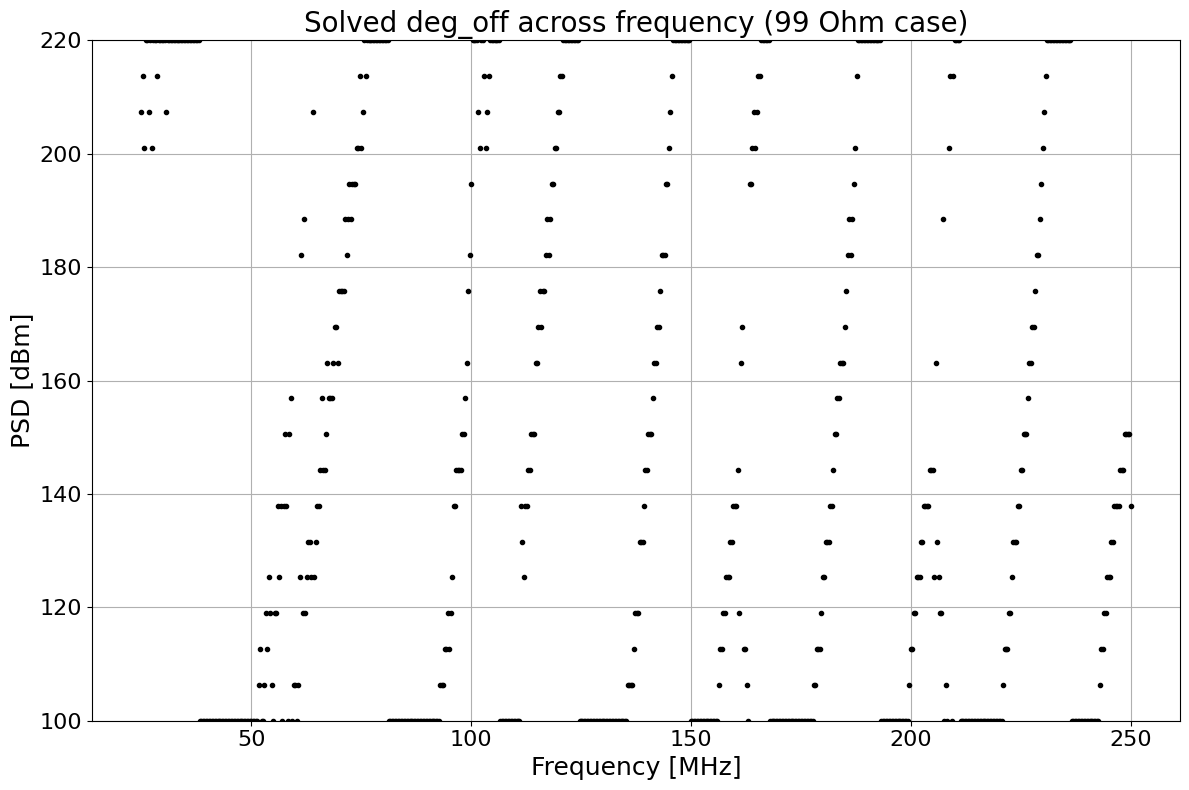

In [67]:
deg_off_99_spec.plot(marker='o', ms=3, ls='', 
        title='Solved deg_off across frequency (99 Ohm case)')

In [68]:
def best_fit_LNA(measured):
    from scipy.optimize import curve_fit
    popt, pcov = curve_fit(LNA_equation, measured.f, measured.s, p0=[0.01, 0.01, 0.01, 3], 
        bounds=([-360, -100, -100, 0], [360, 100, 100, 10]))
    return popt

# popt = best_fit_LNA(LNA_contributions[1])

In [69]:
fitted_LNA = LNA_equation(LNA_contributions[1].f, deg_off_99)
fitted_LNA_spec = Spectrum(LNA_contributions[1].f, fitted_LNA, 
    name='Fitted LNA Noise with Partial Reflection', colorcode='lightblue')

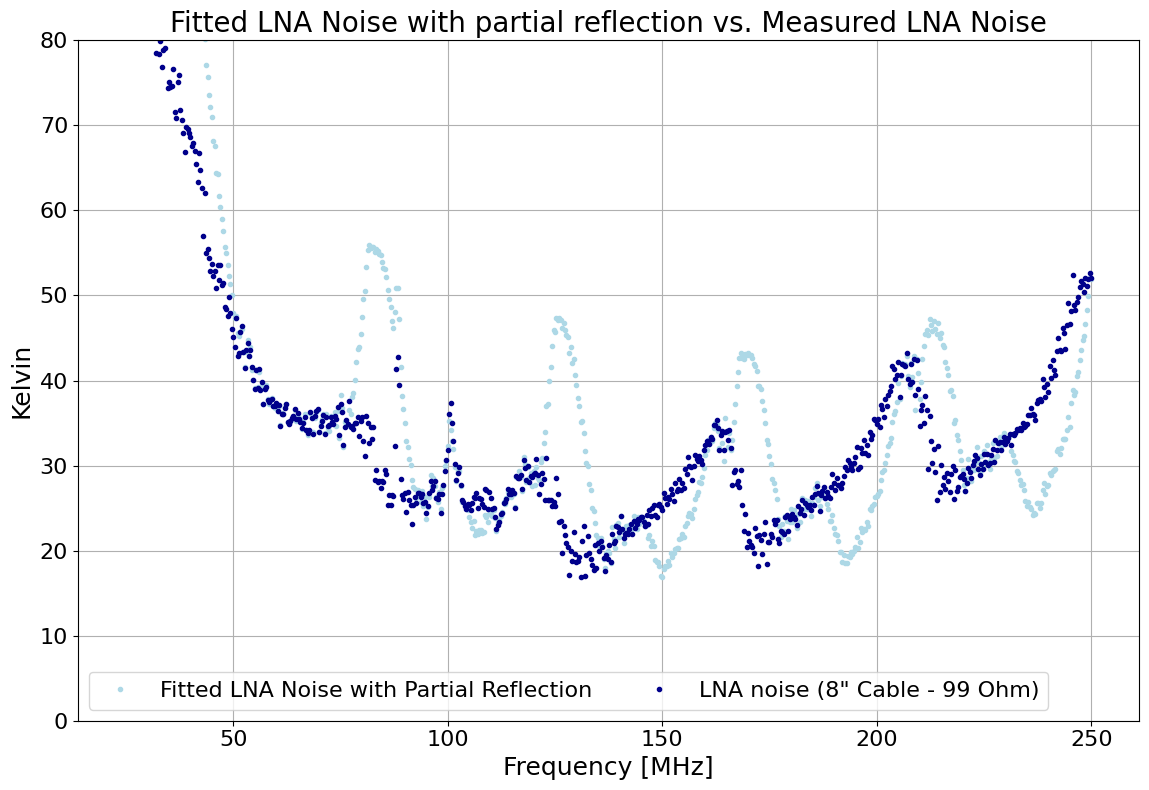

In [70]:
plotter.plot_spectra([fitted_LNA_spec, LNA_contributions[1]], marker='o', ms=3,
    title='Fitted LNA Noise with partial reflection vs. Measured LNA Noise',
    y_range=(0, 80), ls='', ylabel='Kelvin')

In [200]:
from highz_exp.reflection_proc import remove_spikes

def remove_rfi(kelvin_spec, prominence=50, clean_width=7):
    cleaned_f, cleaned_s = remove_spikes(x=kelvin_spec.f, y=kelvin_spec.s, height=50, prominence=prominence, clean_width=clean_width)
    cleaned_f, cleaned_s = remove_spikes(x=cleaned_f, y=-cleaned_s, prominence=prominence, clean_width=clean_width)
    return Spectrum(cleaned_f, -cleaned_s, name=kelvin_spec.name, colorcode=kelvin_spec.colorcode)


In [142]:
def match_s11(s11, target_s11, tolerance=0.1, freq_window=3):
    """
    Parameters:
    s11 (rf.Network): The S11 parameters of the antenna to be matched.
    target_s11 (rf.Network): The target S11 parameters representing the desired impedance match.
    tolerance (float): The tolerance for considering a match.
    
    Returns:
    dict: A dictionary containing the best match frequency, S11 value, and the corresponding impedance.
    """ 
    
    match_mask = np.abs((np.real(s11.z[:, 0, 0]) - np.real(target_s11.z[:, 0, 0])) / np.real(target_s11.z[:, 0, 0])) < tolerance
    match_mask &= np.abs((np.imag(s11.z[:, 0, 0]) - np.imag(target_s11.z[:, 0, 0])) / np.imag(target_s11.z[:, 0, 0])) < tolerance

    matched_freqs = s11.f[match_mask]
    matched_s11_values = s11.s[match_mask, 0, 0]
    

    ntwk = rf.Network(f=matched_freqs, s=matched_s11_values[:, np.newaxis, np.newaxis])
    target_ntwk = rf.Network(f=matched_freqs, s=target_s11.s[match_mask])
    
    return ntwk, target_ntwk